# EU Corpus EDA - Data Ready

Quick validation notebook:
1. Load all 35 documents (7 countries × 5 years)
2. Extract and score full text (no filtering at this stage)
3. Add structural format control variable
4. Export for analysis

**Approach:** Score entire documents now, filter governance sections during analysis if needed.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (13, 7)

print("✓ Libraries ready")

✓ Libraries ready


## 1. Load All Documents

In [2]:
# Load all corpus files
CORPUS_DIR = Path('scraped')
corpus_files = sorted(CORPUS_DIR.glob('*_corpus.txt'))

print(f"Loading {len(corpus_files)} documents...\n")

# Parse and load
documents = []
for filepath in corpus_files:
    # Extract metadata from filename: {country}_{year}_corpus.txt
    parts = filepath.stem.split('_')
    year = int(parts[-2])
    country = '_'.join(parts[:-2])
    
    # Determine structural format
    structural_format = 'narrative' if year <= 2023 else 'chapter-based'
    
    # Load text
    with open(filepath, 'r', encoding='utf-8') as f:
        text = f.read()
    
    documents.append({
        'country': country,
        'year': year,
        'structural_format': structural_format,
        'text': text,
        'total_words': len(text.split())
    })

df = pd.DataFrame(documents).sort_values(['country', 'year']).reset_index(drop=True)

# Summary
print(f"{'Country':<30} {'Year':>5} {'Format':<15} {'Words':>10}")
print("-" * 65)
for _, row in df.iterrows():
    print(f"{row['country'].replace('_', ' ').title():<30} {row['year']:>5} {row['structural_format']:<15} {row['total_words']:>10,}")

print(f"\n{'Total':<30} {len(df):>5} documents | {df['total_words'].sum():>10,} words")
print(f"\nCountries: {df['country'].nunique()}")
print(f"Years: {df['year'].min()}-{df['year'].max()}")

Loading 35 documents...

Country                         Year Format               Words
-----------------------------------------------------------------
Albania                         2021 narrative            3,574
Albania                         2022 narrative            3,369
Albania                         2023 narrative            2,979
Albania                         2024 chapter-based        7,830
Albania                         2025 chapter-based        8,509
Bosnia And Herzegovina          2021 narrative            2,863
Bosnia And Herzegovina          2022 narrative            3,483
Bosnia And Herzegovina          2023 narrative            3,972
Bosnia And Herzegovina          2024 chapter-based        7,894
Bosnia And Herzegovina          2025 chapter-based        7,898
Kosovo                          2021 narrative            2,805
Kosovo                          2022 narrative            6,720
Kosovo                          2023 narrative            2,842
Kosovo       

## 2. Score Full Text (Reform vs. Criticism)

In [3]:
# Reform and criticism dictionaries
reform_words = {
    'progress', 'progressed', 'advanced', 'advances', 'adopted', 'adopting',
    'implemented', 'implementing', 'strengthened', 'strengthens', 'strengthening',
    'improved', 'improving', 'improvement', 'established', 'establishing',
    'achieved', 'achieves', 'achievement', 'accelerated', 'accelerate',
    'completed', 'completion', 'completing', 'good', 'better', 'well',
    'success', 'successful', 'successfully', 'effective', 'effectively',
    'positive', 'positively', 'enhance', 'enhanced', 'enhancement',
    'functional', 'functioning', 'efficient', 'efficiency'
}

criticism_words = {
    'concern', 'concerns', 'concerning', 'weak', 'weaken', 'weakness',
    'lack', 'lacked', 'lacking', 'delayed', 'delay', 'delays',
    'limited', 'limiting', 'incomplete', 'incompleteness', 'decreased',
    'decrease', 'declining', 'decline', 'insufficient', 'insufficiently',
    'challenge', 'challenges', 'challenging', 'persisting', 'persist',
    'persistent', 'backsliding', 'backslide', 'difficult', 'difficulty',
    'fail', 'failed', 'failure', 'failing', 'problem', 'problems',
    'problematic', 'issue', 'issues', 'risk', 'risks', 'serious',
    'seriously', 'remain', 'remains', 'need', 'needs', 'needed',
    'required', 'require', 'worrying', 'worried', 'inadequate',
    'undermining', 'undermine', 'early stage', 'limited preparation'
}

def score_text(text):
    """Score text for reform and criticism language."""
    tokens = text.lower().split()
    total = len(tokens)
    
    reform_count = sum(1 for t in tokens if t in reform_words)
    criticism_count = sum(1 for t in tokens if t in criticism_words)
    
    reform_pct = (reform_count / total * 100) if total > 0 else 0
    criticism_pct = (criticism_count / total * 100) if total > 0 else 0
    net_score = reform_pct - criticism_pct
    
    return reform_count, criticism_count, reform_pct, criticism_pct, net_score

# Score all documents
scores = df['text'].apply(lambda x: pd.Series(score_text(x)))
scores.columns = ['reform_count', 'criticism_count', 'reform_score', 'criticism_score', 'net_score']
df = pd.concat([df, scores], axis=1)

# Display results
print("\nDocument Scores:")
print(f"\n{'Country':<25} {'Year':>5} {'Format':<15} {'Reform%':>8} {'Crit%':>8} {'Net':>8}")
print("-" * 80)
for _, row in df.iterrows():
    country = row['country'].replace('_', ' ').title()
    print(f"{country:<25} {row['year']:>5} {row['structural_format']:<15} {row['reform_score']:>7.2f}% {row['criticism_score']:>7.2f}% {row['net_score']:>7.3f}")

print(f"\nOverall Statistics:")
print(f"  Mean ReformScore: {df['reform_score'].mean():.2f}%")
print(f"  Mean CriticismScore: {df['criticism_score'].mean():.2f}%")
print(f"  Mean NetScore: {df['net_score'].mean():.3f}")


Document Scores:

Country                    Year Format           Reform%    Crit%      Net
--------------------------------------------------------------------------------
Albania                    2021 narrative          1.85%    1.15%   0.699
Albania                    2022 narrative          2.02%    1.63%   0.386
Albania                    2023 narrative          1.98%    1.75%   0.235
Albania                    2024 chapter-based      2.44%    1.34%   1.098
Albania                    2025 chapter-based      2.40%    1.42%   0.975
Bosnia And Herzegovina     2021 narrative          1.78%    1.50%   0.279
Bosnia And Herzegovina     2022 narrative          1.72%    1.49%   0.230
Bosnia And Herzegovina     2023 narrative          1.94%    1.59%   0.352
Bosnia And Herzegovina     2024 chapter-based      1.89%    1.51%   0.380
Bosnia And Herzegovina     2025 chapter-based      1.87%    1.32%   0.557
Kosovo                     2021 narrative          2.17%    1.85%   0.321
Kosovo     

## 3. Visualization

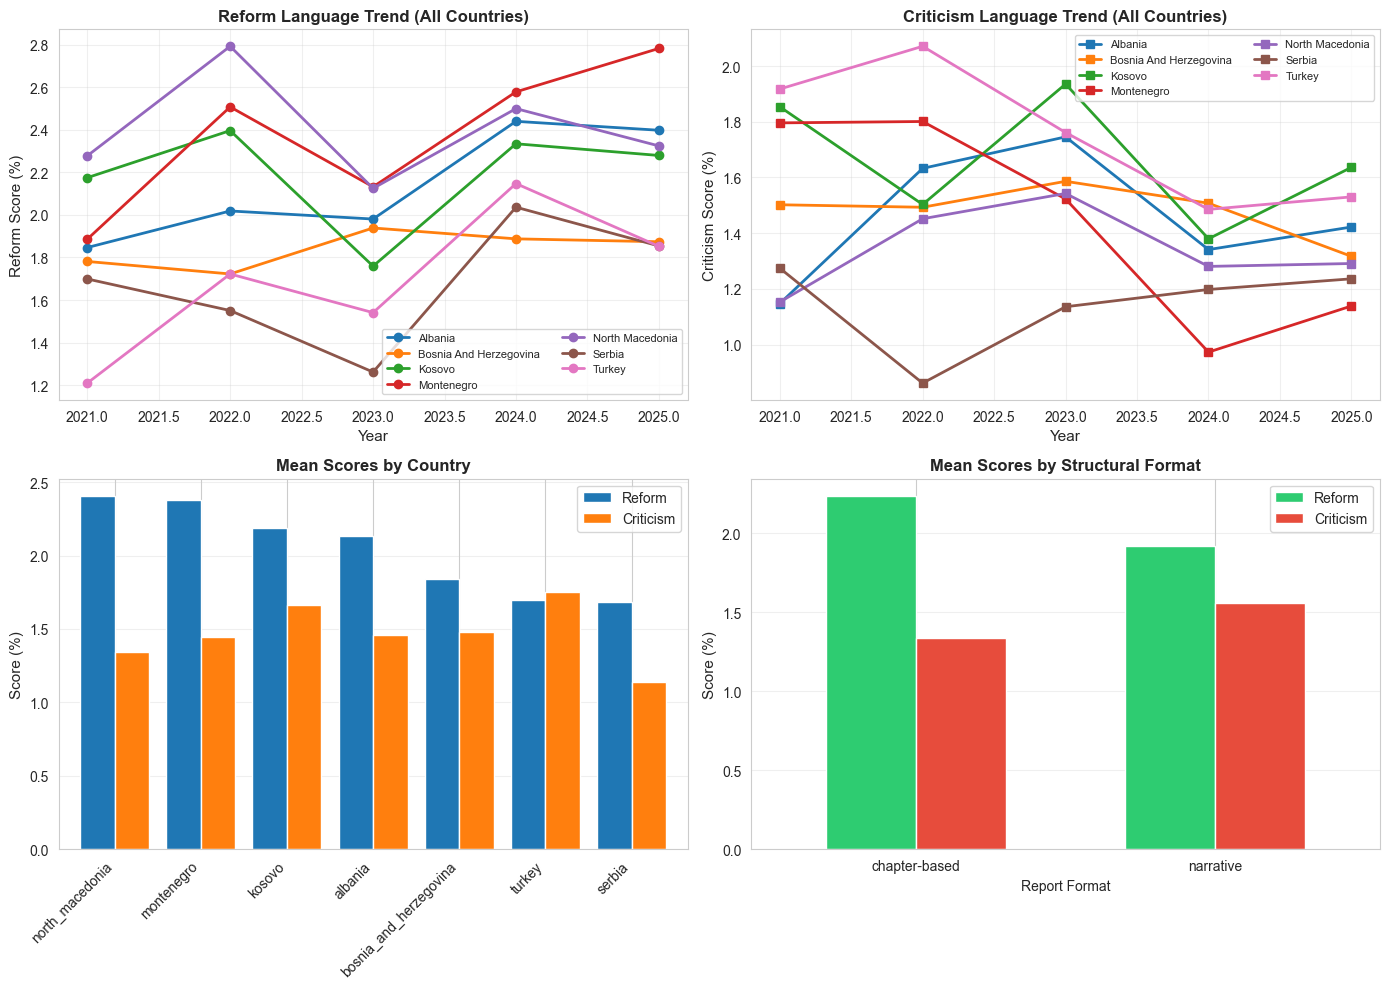

✓ Visualization saved as 'EU_corpus_overview.png'


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Reform scores by country over time
ax = axes[0, 0]
for country in sorted(df['country'].unique()):
    country_df = df[df['country'] == country].sort_values('year')
    ax.plot(country_df['year'], country_df['reform_score'], marker='o', 
            label=country.replace('_', ' ').title(), linewidth=2, markersize=6)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Reform Score (%)', fontsize=11)
ax.set_title('Reform Language Trend (All Countries)', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, ncol=2, loc='best')
ax.grid(True, alpha=0.3)

# 2. Criticism scores by country over time
ax = axes[0, 1]
for country in sorted(df['country'].unique()):
    country_df = df[df['country'] == country].sort_values('year')
    ax.plot(country_df['year'], country_df['criticism_score'], marker='s', 
            label=country.replace('_', ' ').title(), linewidth=2, markersize=6)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Criticism Score (%)', fontsize=11)
ax.set_title('Criticism Language Trend (All Countries)', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, ncol=2, loc='best')
ax.grid(True, alpha=0.3)

# 3. Scores by country (mean across all years)
ax = axes[1, 0]
country_stats = df.groupby('country')[['reform_score', 'criticism_score']].mean().sort_values('reform_score', ascending=False)
country_stats.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Mean Scores by Country', fontsize=12, fontweight='bold')
ax.set_ylabel('Score (%)', fontsize=11)
ax.set_xlabel('')
ax.legend(['Reform', 'Criticism'])
ax.grid(True, alpha=0.3, axis='y')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 4. Scores by structural format
ax = axes[1, 1]
format_stats = df.groupby('structural_format')[['reform_score', 'criticism_score']].mean()
format_stats.plot(kind='bar', ax=ax, width=0.6, color=['#2ecc71', '#e74c3c'])
ax.set_title('Mean Scores by Structural Format', fontsize=12, fontweight='bold')
ax.set_ylabel('Score (%)', fontsize=11)
ax.set_xlabel('Report Format')
ax.legend(['Reform', 'Criticism'])
ax.grid(True, alpha=0.3, axis='y')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('EU_corpus_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Visualization saved as 'EU_corpus_overview.png'")

## 4. Data Quality Check

In [5]:
print("\n" + "="*75)
print("✓ DATA VALIDATION")
print("="*75)

print(f"\nDocuments Loaded:")
print(f"  Total: {len(df)} documents")
print(f"  Countries: {df['country'].nunique()}")
for country in sorted(df['country'].unique()):
    count = len(df[df['country']==country])
    print(f"    - {country.replace('_', ' ').title()}: {count} documents")

print(f"\n  Time Period: {df['year'].min()}-{df['year'].max()} ({len(df['year'].unique())} years)")
print(f"  Total Text: {df['total_words'].sum():,} words")

print(f"\nStructural Format (Control Variable):")
for fmt in sorted(df['structural_format'].unique()):
    count = len(df[df['structural_format']==fmt])
    years = sorted(df[df['structural_format']==fmt]['year'].unique())
    print(f"  - {fmt}: {count} documents ({years[0]}-{years[-1]})")

print(f"\nScoring Results:")
print(f"  All documents scored: {len(df[df['reform_score'].notna()])} ✓")
print(f"  No missing values: {df[['reform_score', 'criticism_score']].isna().sum().sum() == 0} ✓")

print(f"\nScore Ranges:")
print(f"  Reform Score: {df['reform_score'].min():.2f}% to {df['reform_score'].max():.2f}%")
print(f"  Criticism Score: {df['criticism_score'].min():.2f}% to {df['criticism_score'].max():.2f}%")
print(f"  Net Score: {df['net_score'].min():.3f} to {df['net_score'].max():.3f}")

print(f"\n" + "="*75)
print("✓✓✓ CORPUS READY FOR ANALYSIS ✓✓✓")
print("="*75)


✓ DATA VALIDATION

Documents Loaded:
  Total: 35 documents
  Countries: 7
    - Albania: 5 documents
    - Bosnia And Herzegovina: 5 documents
    - Kosovo: 5 documents
    - Montenegro: 5 documents
    - North Macedonia: 5 documents
    - Serbia: 5 documents
    - Turkey: 5 documents

  Time Period: 2021-2025 (5 years)
  Total Text: 188,566 words

Structural Format (Control Variable):
  - chapter-based: 14 documents (2024-2025)
  - narrative: 21 documents (2021-2023)

Scoring Results:
  All documents scored: 35 ✓
  No missing values: True ✓

Score Ranges:
  Reform Score: 1.21% to 2.79%
  Criticism Score: 0.86% to 2.07%
  Net Score: -0.707 to 1.643

✓✓✓ CORPUS READY FOR ANALYSIS ✓✓✓


## 5. Export for Analysis

In [6]:
# Create export dataframe (keep text for manual filtering later if needed)
export_df = df[[
    'country', 'year', 'structural_format',
    'total_words', 'reform_count', 'criticism_count',
    'reform_score', 'criticism_score', 'net_score'
]].copy()

export_df.to_csv('EU_corpus_scores.csv', index=False)
print(f"✓ Scores exported to 'EU_corpus_scores.csv'")
print(f"\n{export_df.to_string(index=False)}")

✓ Scores exported to 'EU_corpus_scores.csv'

               country  year structural_format  total_words  reform_count  criticism_count  reform_score  criticism_score  net_score
               albania  2021         narrative         3574          66.0             41.0      1.846670         1.147174   0.699496
               albania  2022         narrative         3369          68.0             55.0      2.018403         1.632532   0.385871
               albania  2023         narrative         2979          59.0             52.0      1.980530         1.745552   0.234978
               albania  2024     chapter-based         7830         191.0            105.0      2.439336         1.340996   1.098340
               albania  2025     chapter-based         8509         204.0            121.0      2.397462         1.422024   0.975438
bosnia_and_herzegovina  2021         narrative         2863          51.0             43.0      1.781348         1.501921   0.279427
bosnia_and_herzegovina  

## 6. Summary for Paper

In [7]:
print("\n" + "="*75)
print("SUMMARY STATISTICS FOR PAPER")
print("="*75)

print(f"\nSample:")
print(f"  N = {len(df)} country-year observations")
print(f"  Countries: {df['country'].nunique()} (Albania, Bosnia & Herzegovina, Kosovo,")
print(f"             Montenegro, North Macedonia, Serbia, Turkey)")
print(f"  Time period: {df['year'].min()}-{df['year'].max()}")
print(f"  Total tokens: {df['total_words'].sum():,}")

print(f"\nMain Variables:")
print(f"\n  Reform Score (%)")
print(f"    Mean: {df['reform_score'].mean():.3f}")
print(f"    SD: {df['reform_score'].std():.3f}")
print(f"    Min: {df['reform_score'].min():.3f}, Max: {df['reform_score'].max():.3f}")

print(f"\n  Criticism Score (%)")
print(f"    Mean: {df['criticism_score'].mean():.3f}")
print(f"    SD: {df['criticism_score'].std():.3f}")
print(f"    Min: {df['criticism_score'].min():.3f}, Max: {df['criticism_score'].max():.3f}")

print(f"\n  Net Score (Reform - Criticism)")
print(f"    Mean: {df['net_score'].mean():.3f}")
print(f"    SD: {df['net_score'].std():.3f}")
print(f"    Min: {df['net_score'].min():.3f}, Max: {df['net_score'].max():.3f}")

print(f"\nVariation by Structural Format:")
for fmt in sorted(df['structural_format'].unique()):
    subset = df[df['structural_format']==fmt]
    print(f"  {fmt} (n={len(subset)}):")
    print(f"    Reform: {subset['reform_score'].mean():.3f} (SD: {subset['reform_score'].std():.3f})")
    print(f"    Criticism: {subset['criticism_score'].mean():.3f} (SD: {subset['criticism_score'].std():.3f})")

print(f"\nVariation by Country (mean across all years):")
for country in sorted(df['country'].unique()):
    subset = df[df['country']==country]
    country_name = country.replace('_', ' ').title()
    print(f"  {country_name:<25} Reform: {subset['reform_score'].mean():.3f} | Criticism: {subset['criticism_score'].mean():.3f} | N={len(subset)}")

print(f"\nTemporal Trends (mean across all countries):")
for year in sorted(df['year'].unique()):
    subset = df[df['year']==year]
    print(f"  {year}: Reform={subset['reform_score'].mean():.3f} | Criticism={subset['criticism_score'].mean():.3f} | N={len(subset)}")


SUMMARY STATISTICS FOR PAPER

Sample:
  N = 35 country-year observations
  Countries: 7 (Albania, Bosnia & Herzegovina, Kosovo,
             Montenegro, North Macedonia, Serbia, Turkey)
  Time period: 2021-2025
  Total tokens: 188,566

Main Variables:

  Reform Score (%)
    Mean: 2.046
    SD: 0.384
    Min: 1.210, Max: 2.792

  Criticism Score (%)
    Mean: 1.469
    SD: 0.283
    Min: 0.862, Max: 2.071

  Net Score (Reform - Criticism)
    Mean: 0.577
    SD: 0.522
    Min: -0.707, Max: 1.643

Variation by Structural Format:
  chapter-based (n=14):
    Reform: 2.235 (SD: 0.299)
    Criticism: 1.338 (SD: 0.174)
  narrative (n=21):
    Reform: 1.920 (SD: 0.389)
    Criticism: 1.556 (SD: 0.310)

Variation by Country (mean across all years):
  Albania                   Reform: 2.136 | Criticism: 1.458 | N=5
  Bosnia And Herzegovina    Reform: 1.841 | Criticism: 1.481 | N=5
  Kosovo                    Reform: 2.189 | Criticism: 1.662 | N=5
  Montenegro                Reform: 2.377 | Cri